# Exploratory Data Analysis (EDA) on Congestion Dataset
This notebook loads `congestion_dataset_v4.csv` and performs basic exploratory data analysis, plotting data distributions, checking for class imbalance, and generating correlation matrices.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set display settings for better output
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 1. Data Loading & Basic Summary

In [ ]:
print("Loading dataset...")
df = pd.read_csv("congestion_dataset_v5.csv")

print(f"\nDataset Shape: {df.shape}")
print("\n--- First 5 rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

Loading dataset...

Dataset Shape: (50000, 142)

--- First 5 rows ---


,pd_bus_0,pd_bus_1,pd_bus_2,pd_bus_3,pd_bus_4,pd_bus_5,pd_bus_6,pd_bus_7,pd_bus_8,pd_bus_9,pd_bus_10,pd_bus_11,pd_bus_12,pd_bus_13,pd_bus_14,pd_bus_15,pd_bus_16,pd_bus_17,pd_bus_18,pd_bus_19,pd_bus_20,qd_bus_0,qd_bus_1,qd_bus_2,qd_bus_3,qd_bus_4,qd_bus_5,qd_bus_6,qd_bus_7,qd_bus_8,qd_bus_9,qd_bus_10,qd_bus_11,qd_bus_12,qd_bus_13,qd_bus_14,qd_bus_15,qd_bus_16,qd_bus_17,qd_bus_18,qd_bus_19,qd_bus_20,gen_status_0,gen_status_1,gen_status_2,gen_status_3,gen_status_4,gen_status_5,rmax_0,rmax_1,rmax_2,rmax_3,rmax_4,rmax_5,rmin_0,rmin_1,rmin_2,rmin_3,rmin_4,rmin_5,branch_status_0,branch_status_1,branch_status_2,branch_status_3,branch_status_4,branch_status_5,branch_status_6,branch_status_7,branch_status_8,branch_status_9,branch_status_10,branch_status_11,branch_status_12,branch_status_13,branch_status_14,branch_status_15,branch_status_16,branch_status_17,branch_status_18,branch_status_19,branch_status_20,branch_status_21,branch_status_22,branch_status_23,branch_status_24,branch_status_25,branch_status_26,branch_status_27,branch_status_28,branch_status_29,branch_status_30,branch_status_31,branch_status_32,branch_status_33,branch_status_34,branch_status_35,branch_status_36,branch_status_37,branch_status_38,branch_status_39,branch_status_40,cong_branch_0,cong_branch_1,cong_branch_2,cong_branch_3,cong_branch_4,cong_branch_5,cong_branch_6,cong_branch_7,cong_branch_8,cong_branch_9,cong_branch_10,cong_branch_11,cong_branch_12,cong_branch_13,cong_branch_14,cong_branch_15,cong_branch_16,cong_branch_17,cong_branch_18,cong_branch_19,cong_branch_20,cong_branch_21,cong_branch_22,cong_branch_23,cong_branch_24,cong_branch_25,cong_branch_26,cong_branch_27,cong_branch_28,cong_branch_29,cong_branch_30,cong_branch_31,cong_branch_32,cong_branch_33,cong_branch_34,cong_branch_35,cong_branch_36,cong_branch_37,cong_branch_38,cong_branch_39,cong_branch_40
0,0.150020,0.015372,0.055922,0.711851,0.146297,0.214138,0.030737,0.061279,0.037964,0.045690,0.025470,0.064991,0.024394,0.072482,0.016791,0.113002,0.021131,0.047319,0.019251,0.017490,0.071247,0.096380,0.008798,0.011566,0.109455,0.068498,0.222562,0.013594,0.043497,0.009135,0.018093,0.012951,0.034137,0.005168,0.024114,0.005091,0.080743,0.011770,0.049238,0.014540,0.005659,0.011634,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.136082,0.014540,0.064272,0.796291,0.141740,0.255266,0.043077,0.082459,0.038307,0.058478,0.024874,0.053031,0.018629,0.061787,0.016189,0.118563,0.018617,0.074221,0.020123,0.015392,0.063575,0.100683,0.009585,0.010731,0.122117,0.078436,0.186456,0.016256,0.045750,0.010075,0.015084,0.011620,0.035668,0.007600,0.019534,0.004828,0.089651,0.011913,0.038171,0.016619,0.005807,0.014242,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
2,0.167406,0.020223,0.049531,0.778679,0.152191,0.255833,0.035031,0.091054,0.052704,0.062346,0.029545,0.061868,0.019508,0.067753,0.018462,0.143775,0.022607,0.072349,0.029991,0.016435,0.091901,0.112191,0.008329,0.011922,0.122307,0.084383,0.229482,0.016248,0.060212,0.014088,0.021139,0.012718,0.043917,0.007803,0.024495,0.004682,0.085361,0.011705,0.052225,0.015915,0.006614,0.016862,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 142 entries, pd_bus_0 to cong_branch_40
dtypes: float64(142)
memory usage: 54.2 MB


## 2. Missing Values & Summary Statistics

In [ ]:
missing_values = df.isnull().sum()
print("Missing Values by Column:\n", missing_values[missing_values > 0])

print("\n--- Summary Statistics (Numeric Features) ---")
display(df.describe())

Missing Values by Column:
 Series([], dtype: int64)

--- Summary Statistics (Numeric Features) ---


,pd_bus_0,pd_bus_1,pd_bus_2,pd_bus_3,pd_bus_4,pd_bus_5,pd_bus_6,pd_bus_7,pd_bus_8,pd_bus_9,pd_bus_10,pd_bus_11,pd_bus_12,pd_bus_13,pd_bus_14,pd_bus_15,pd_bus_16,pd_bus_17,pd_bus_18,pd_bus_19,pd_bus_20,qd_bus_0,qd_bus_1,qd_bus_2,qd_bus_3,qd_bus_4,qd_bus_5,qd_bus_6,qd_bus_7,qd_bus_8,qd_bus_9,qd_bus_10,qd_bus_11,qd_bus_12,qd_bus_13,qd_bus_14,qd_bus_15,qd_bus_16,qd_bus_17,qd_bus_18,qd_bus_19,qd_bus_20,gen_status_0,gen_status_1,gen_status_2,gen_status_3,gen_status_4,gen_status_5,rmax_0,rmax_1,rmax_2,rmax_3,rmax_4,rmax_5,rmin_0,rmin_1,rmin_2,rmin_3,rmin_4,rmin_5,branch_status_0,branch_status_1,branch_status_2,branch_status_3,branch_status_4,branch_status_5,branch_status_6,branch_status_7,branch_status_8,branch_status_9,branch_status_10,branch_status_11,branch_status_12,branch_status_13,branch_status_14,branch_status_15,branch_status_16,branch_status_17,branch_status_18,branch_status_19,branch_status_20,branch_status_21,branch_status_22,branch_status_23,branch_status_24,branch_status_25,branch_status_26,branch_status_27,branch_status_28,branch_status_29,branch_status_30,branch_status_31,branch_status_32,branch_status_33,branch_status_34,branch_status_35,branch_status_36,branch_status_37,branch_status_38,branch_status_39,branch_status_40,cong_branch_0,cong_branch_1,cong_branch_2,cong_branch_3,cong_branch_4,cong_branch_5,cong_branch_6,cong_branch_7,cong_branch_8,cong_branch_9,cong_branch_10,cong_branch_11,cong_branch_12,cong_branch_13,cong_branch_14,cong_branch_15,cong_branch_16,cong_branch_17,cong_branch_18,cong_branch_19,cong_branch_20,cong_branch_21,cong_branch_22,cong_branch_23,cong_branch_24,cong_branch_25,cong_branch_26,cong_branch_27,cong_branch_28,cong_branch_29,cong_branch_30,cong_branch_31,cong_branch_32,cong_branch_33,cong_branch_34,cong_branch_35,cong_branch_36,cong_branch_37,cong_branch_38,cong_branch_39,cong_branch_40
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.000000,50000.000000,50000.0,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.000000,50000.000000,50000.0,50000.0,50000.0,50000.000000,50000.000000
mean,0.173292,0.019181,0.060724,0.750542,0.181971,0.239388,0.046260,0.089479,0.049499,0.065518,0.027950,0.071802,0.025568,0.075864,0.017565,0.139732,0.025568,0.069517,0.027941,0.019166,0.084656,0.101512,0.009585,0.012768,0.151854,0.087071,0.239500,0.015987,0.059917,0.012772,0.019971,0.014382,0.046338,0.007184,0.027131,0.005593,0.089482,0.012771,0.053490,0.018371,0.007192,0.015173,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0

## 3. Class Distribution (Congestion)

Found target column: cong_branch_0


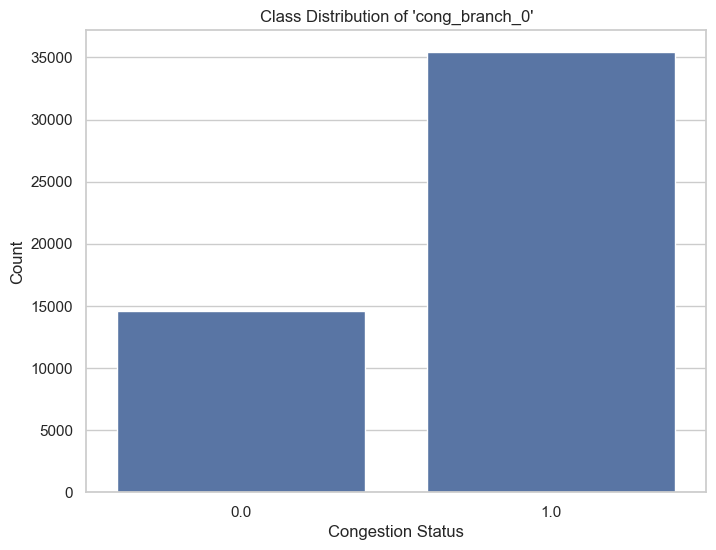

Class Counts:
 cong_branch_0
1.0    35423
0.0    14577
Name: count, dtype: int64

Class Proportions:
 cong_branch_0
1.0    0.70846
0.0    0.29154
Name: proportion, dtype: float64


In [ ]:
# Find congestion column
target_col = [c for c in df.columns if 'cong' in c.lower()]
if target_col:
    target_col = target_col[0]
    print(f"Found target column: {target_col}")
    
    plt.figure(figsize=(8, 6))
    sns.countplot(x=target_col, data=df)
    plt.title(f"Class Distribution of '{target_col}'")
    plt.xlabel("Congestion Status")
    plt.ylabel("Count")
    plt.show()
    
    print("Class Counts:\n", df[target_col].value_counts())
    print("\nClass Proportions:\n", df[target_col].value_counts(normalize=True))
else:
    print("No column containing 'congest' found.")

## 4. Feature Correlations

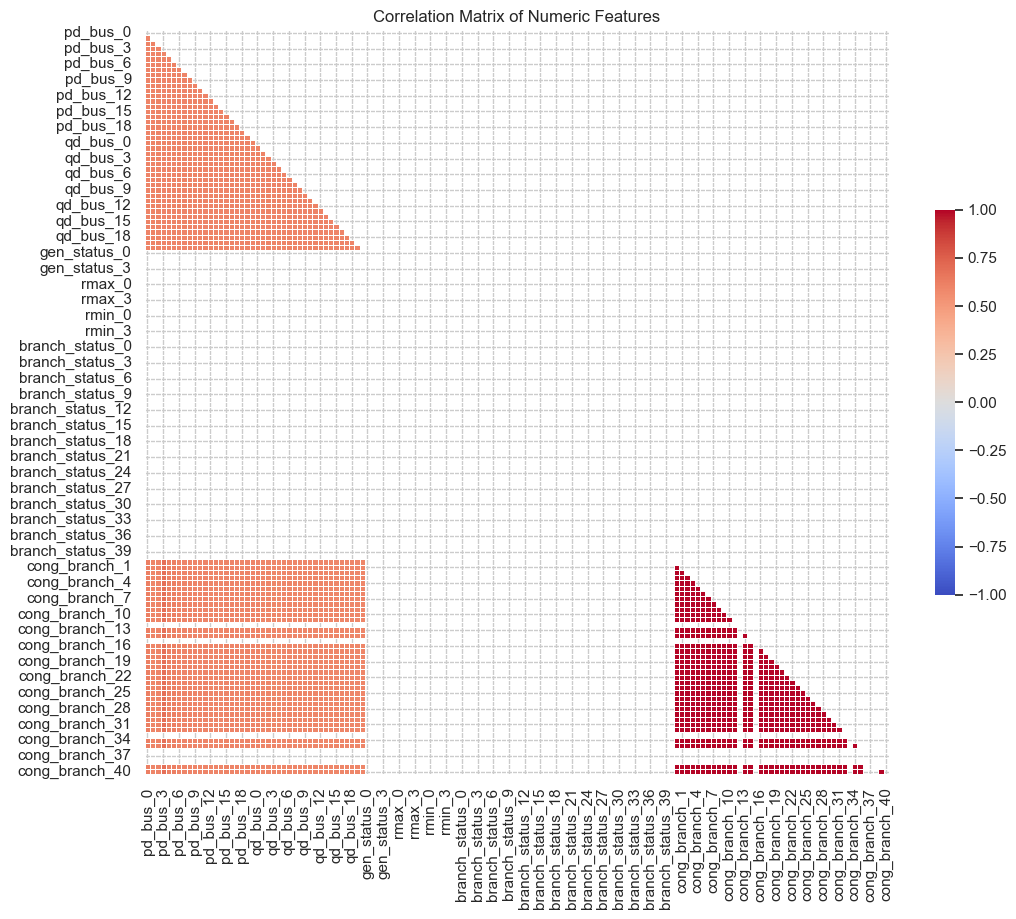

In [ ]:
# Separate numeric columns
numeric_df = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])

if len(numeric_df.columns) > 1:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", vmax=1.0, vmin=-1.0, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Correlation Matrix of Numeric Features")
    plt.show()
else:
    print("Not enough numeric features to plot correlation matrix.")

## 5. Feature Distributions vs Congestion

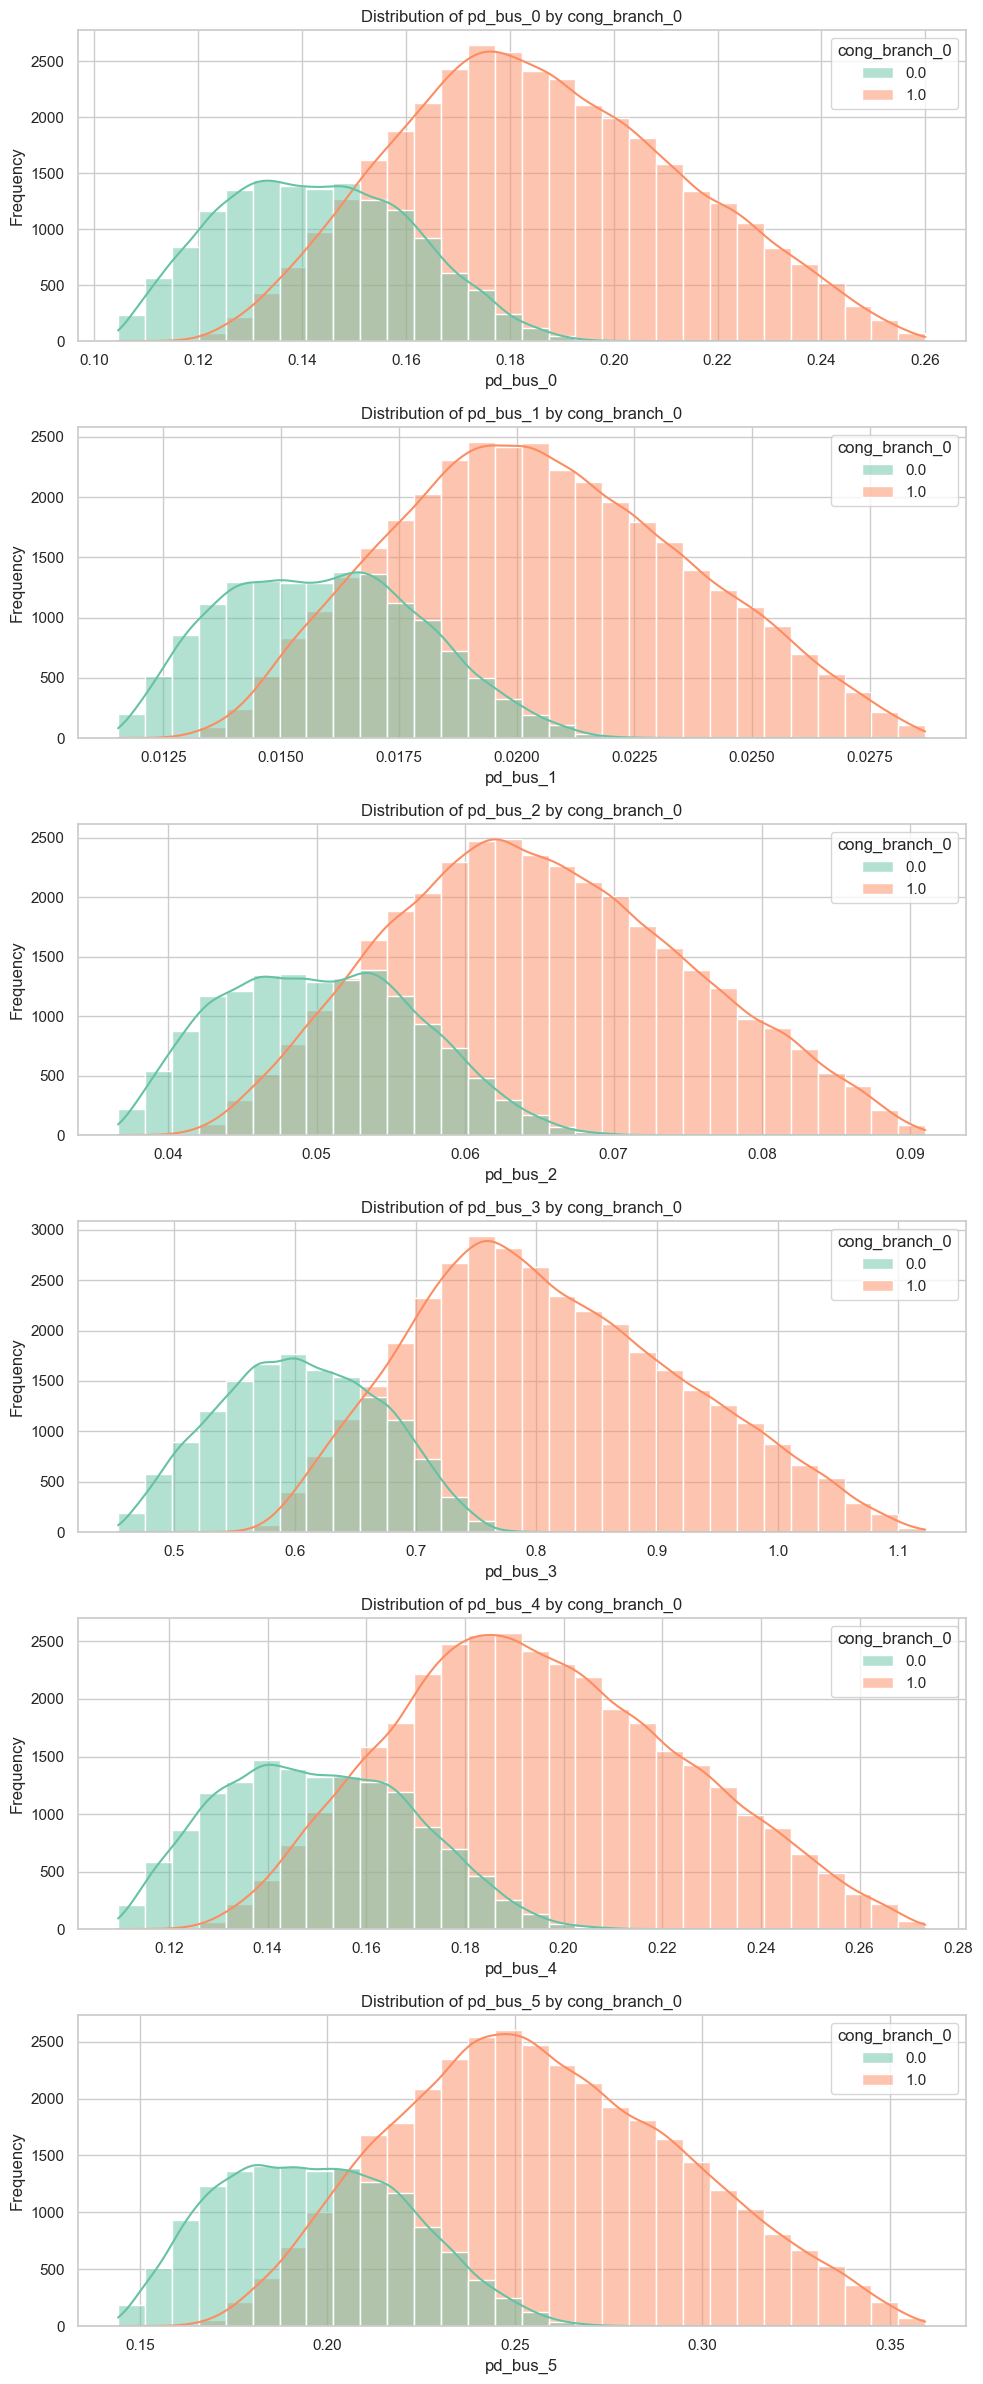

In [ ]:
if target_col and len(numeric_df.columns) > 1:
    # Select a few features to plot (exclude identifiers like ID/Index and the target itself)
    exclude = [target_col, 'Unnamed: 0', 'id', 'index']
    features_to_plot = [c for c in numeric_df.columns if c.lower() not in [e.lower() for e in exclude]][:6]
    
    if len(features_to_plot) > 0:
        fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(10, 4 * len(features_to_plot)))
        if len(features_to_plot) == 1:
            axes = [axes]
        
        for ax, feat in zip(axes, features_to_plot):
            sns.histplot(data=df, x=feat, hue=target_col, kde=True, bins=30, ax=ax, palette="Set2")
            ax.set_title(f"Distribution of {feat} by {target_col}")
            ax.set_xlabel(feat)
            ax.set_ylabel("Frequency")
            
        plt.tight_layout()
        plt.show()

## 6. Distribution Across All Branches
Analyzing the counts of congestion and active status per branch across the entire dataset.

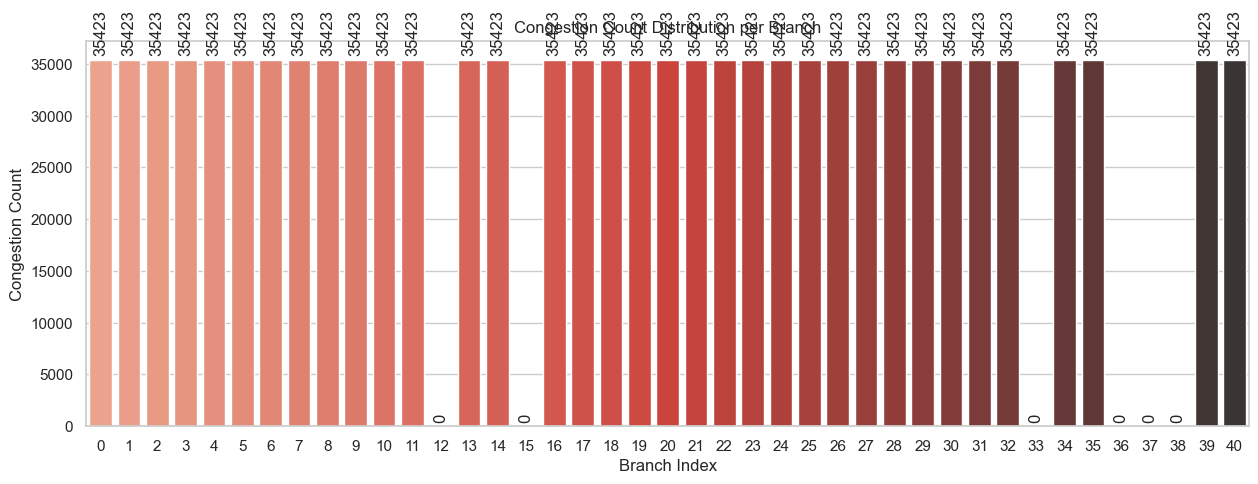

In [ ]:
# Select congestion and branch status columns across all branches
cong_cols = [c for c in df.columns if 'congest' in c.lower() or 'cong_branch' in c.lower()]
status_cols = [c for c in df.columns if 'branch_status_' in c.lower()]

# 1. Congestion Distribution across branches
if len(cong_cols) > 0:
    plt.figure(figsize=(15, 5))
    cong_counts = df[cong_cols].sum()
    x_labels_cong = [c.replace('cong_branch_', '').replace('congest_', '') for c in cong_cols]
    ax1 = sns.barplot(x=x_labels_cong, y=cong_counts.values, hue=x_labels_cong, legend=False, palette="Reds_d")
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.0f', padding=3, rotation=90)
    plt.title("Congestion Count Distribution per Branch")
    plt.xlabel("Branch Index")
    plt.ylabel("Congestion Count")
    plt.show()

